In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import joblib
import pickle

In [2]:
df = pd.read_csv("Iris.csv")

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.shape

(150, 6)

In [5]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [7]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [8]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

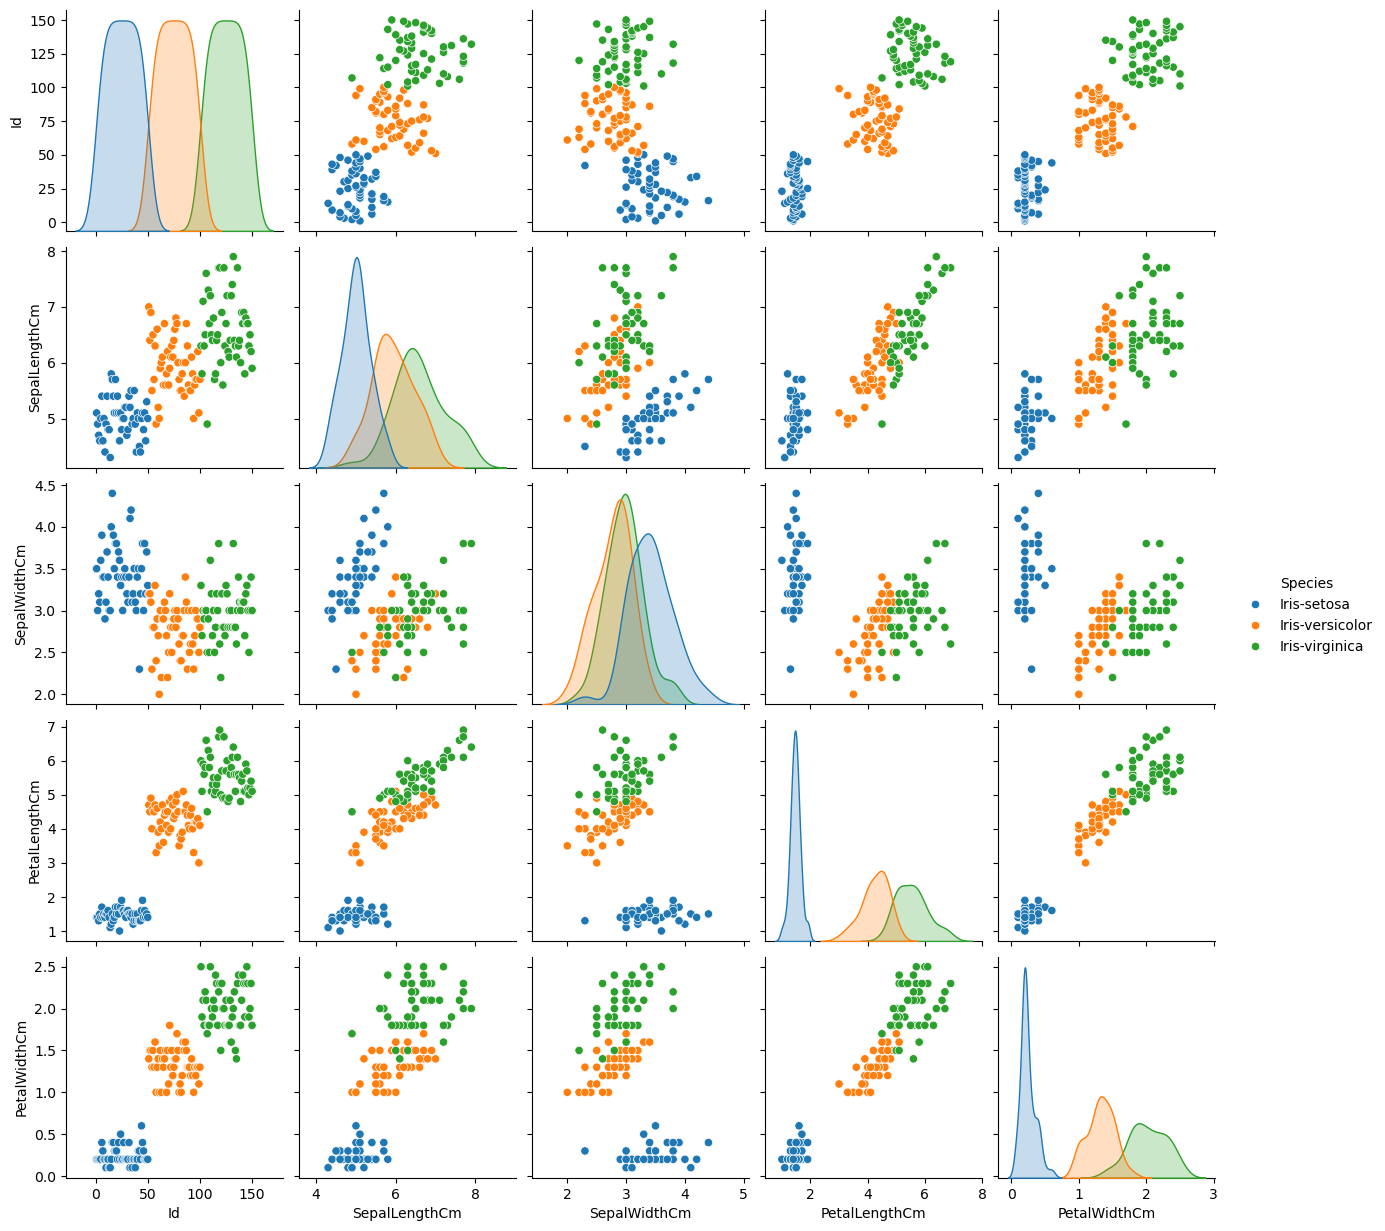

In [9]:
sns.pairplot(df,hue="Species")
plt.show()

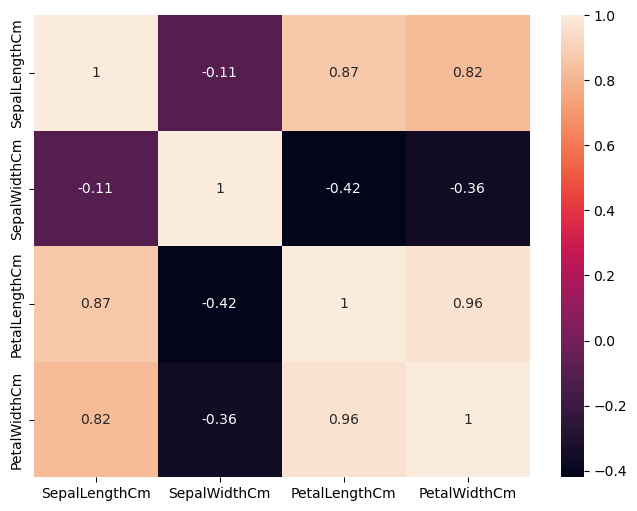

In [10]:
plt.figure(figsize=(8,6))

sns.heatmap(df.drop("Id",axis=1).corr(numeric_only=True),
annot=True)

plt.show()

In [11]:
X = df.drop(["Id","Species"],axis=1)

In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

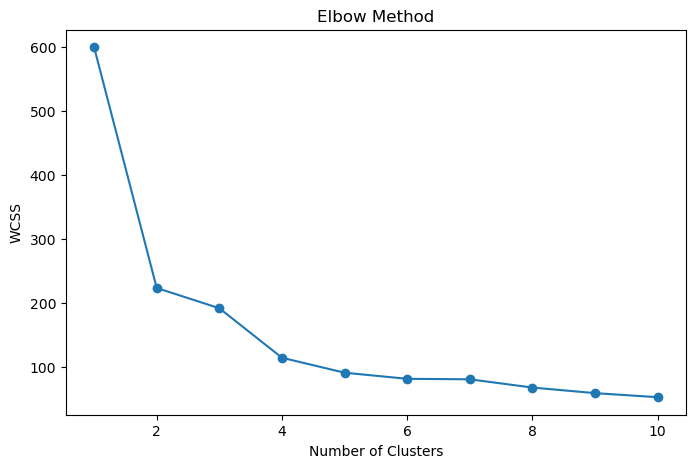

In [14]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [20]:
kmeans=KMeans(n_clusters=3,
              random_state=42)

clusters=kmeans.fit_predict(X_scaled)


In [21]:
df["Cluster"]=clusters

In [23]:
import warnings
warnings.filterwarnings("ignore")

In [24]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Cluster
0,1,5.1,3.5,1.4,0.2,Iris-setosa,1
1,2,4.9,3.0,1.4,0.2,Iris-setosa,2
2,3,4.7,3.2,1.3,0.2,Iris-setosa,2
3,4,4.6,3.1,1.5,0.2,Iris-setosa,2
4,5,5.0,3.6,1.4,0.2,Iris-setosa,1


In [25]:
kmeans.cluster_centers_

array([[ 0.57100359, -0.36600236,  0.69108416,  0.66322635],
       [-0.80601877,  1.33577362, -1.28618375, -1.21026347],
       [-1.31926109, -0.34584225, -1.14482725, -1.1336954 ]])

In [26]:
centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X.columns
)

centers

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,0.571004,-0.366002,0.691084,0.663226
1,-0.806019,1.335774,-1.286184,-1.210263
2,-1.319261,-0.345842,-1.144827,-1.133695


In [27]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [28]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Cluster
0,1,5.1,3.5,1.4,0.2,Iris-setosa,1
1,2,4.9,3.0,1.4,0.2,Iris-setosa,2
2,3,4.7,3.2,1.3,0.2,Iris-setosa,2
3,4,4.6,3.1,1.5,0.2,Iris-setosa,2
4,5,5.0,3.6,1.4,0.2,Iris-setosa,1


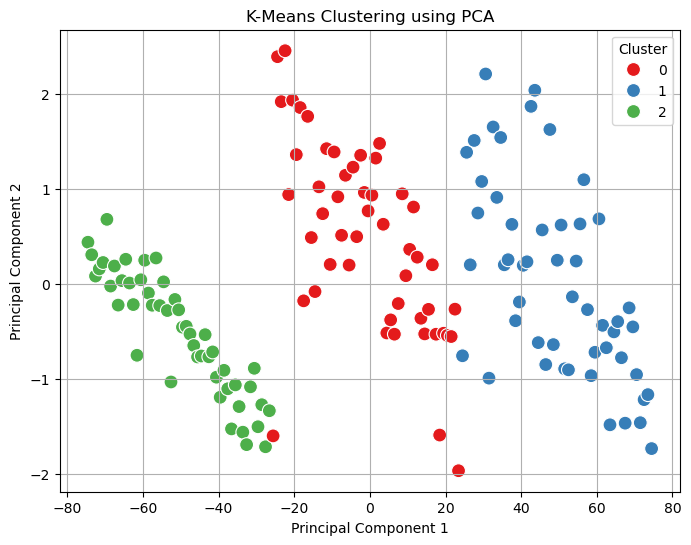

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pandas as pd

# Assuming you have a DataFrame 'df' with numerical features for clustering
# First, perform PCA transformation
pca = PCA(n_components=2)  # Reduce to 2 components for visualization
pca_result = pca.fit_transform(df.select_dtypes(include=['float64', 'int64']))  # Select only numerical columns

# Add PCA results to the DataFrame
df['PCA1'] = pca_result[:, 0]  # First principal component
df['PCA2'] = pca_result[:, 1]  # Second principal component

# Perform K-Means clustering (assuming you want 3 clusters, adjust as needed)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(pca_result)

# Now create the plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set1",
    s=100
)

plt.title("K-Means Clustering using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

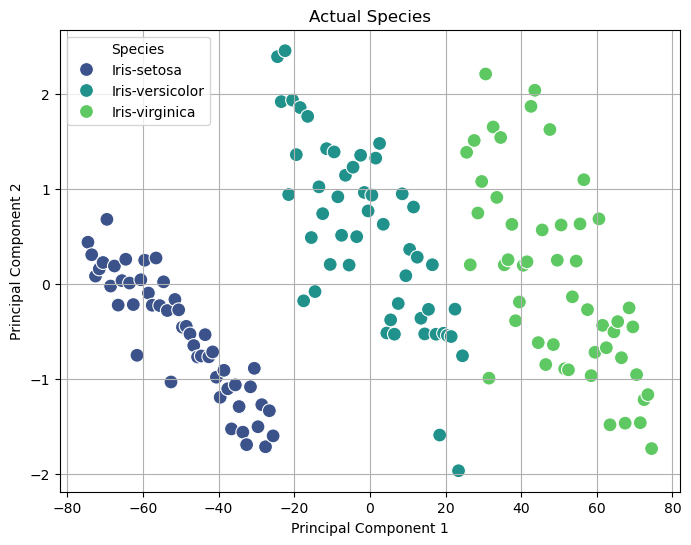

In [32]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="Species",
    palette="viridis",
    s=100
)

plt.title("Actual Species")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

In [33]:
comparison = pd.crosstab(
    df["Species"],
    df["Cluster"]
)

comparison

Cluster,0,1,2
Species,,,
Iris-setosa,1,0,49
Iris-versicolor,49,1,0
Iris-virginica,0,50,0


In [34]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[9.99319101e-01 5.14403271e-04]


In [35]:
print("Total Variance:",
      sum(pca.explained_variance_ratio_))

Total Variance: 0.9998335041805886


In [36]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")

['kmeans_model.pkl']

In [37]:
loaded_model = joblib.load("kmeans_model.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully


In [38]:
import pickle

with open("kmeans_pickle.pkl", "wb") as file:
    pickle.dump(kmeans, file)

In [39]:
with open("kmeans_pickle.pkl", "rb") as file:
    model = pickle.load(file)

print("Pickle Model Loaded Successfully")

Pickle Model Loaded Successfully
